# Football player statistics across 6 seasons (2020–2026)


We had a raw dataset which had too many missing values and duplicated columns. As we merged 30 different datasets into one and some of the datasets had similar columns but in the big dataset those columns appeared as different columns. Thus we had to go through rigorous cleaning check for correleation between every columns and make decision about which columns to keep and which to drop.

After that, we focused on the missing values. Most of the missing values occured beceause of goalkeeper related columns. As an outfield player is not supposed to have any data in those columns thus we tried to impute. We have two options here. One is to impute them with zero. Another one is to impute them with NaN. Both has pros and cons. Thus at that stage we are going to make two different datasets from this one. The one with NaN will be used in XGBoost alogrithm and the other will be used in different purpose.

# In this dataset we will not impute the missing values as it will be used in tree based models

In [41]:
#summoning everything there is known to mankind
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

In [42]:
from google.colab import drive
drive.mount('/content/drive')

#Loading the data
df = pd.read_csv('/content/drive/MyDrive/Ready-to-work-and-sorted-20-26.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Player,Nation,Pos,Squad,Comp,Age,Born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,...,Performance_2CrdY,Performance_Fls,Performance_Fld,Performance_Off,Performance_Crs,Performance_Int,Performance_TklW,Performance_PKwon,Performance_OG,season
0,Aaron Anselmino,ar ARG,DF,Dortmund,de Bundesliga,21-023,2005.0,6.0,4.0,368.0,...,0.0,6.0,3.0,0.0,2.0,7.0,8.0,NaN,0.0,2025-2026
1,Aaron Anselmino,ar ARG,DF,Strasbourg,fr Ligue 1,21-023,2005.0,3.0,0.0,16.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,NaN,0.0,2025-2026
2,Aaron Anselmino,NaN,NaN,Chelsea,NaN,19.0,2005.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-2025
3,Aaron Ciammaglichella,it ITA,MF,Torino,it Serie A,19.0,2005.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,2024-2025
4,Aaron Ciammaglichella,NaN,NaN,Torino,NaN,17.0,2005.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-2023


In [43]:
df.shape

(21100, 85)

In [44]:
sorted(df['season'].unique())

['2020-2021', '2021-2022', '2022-2023', '2023-2024', '2024-2025', '2025-2026']

In [45]:
df.dtypes.value_counts()


,count
float64,67
object,13
int64,5


In [46]:
df.isnull().sum()

,0
Player,0
Nation,3959
Pos,3951
Squad,0
Comp,3951
...,...
Performance_Int,3951
Performance_TklW,3951
Performance_PKwon,21100
Performance_OG,3951


In [47]:
def clean_age(age_val):
    if pd.isna(age_val):
        return np.nan
    try:
        # If it's already a number, return it
        return float(age_val)
    except ValueError:
        # If it's a string like '21-023', extract the year part
        if isinstance(age_val, str) and '-' in age_val:
            return float(age_val.split('-')[0])
        return np.nan # Handle other unexpected string formats

# Apply the cleaning function to the 'Age' column
df['Age'] = df['Age'].apply(clean_age)

# Convert the 'Age' column to numeric, coercing errors to NaN
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

print("Age column cleaned and converted to numeric.")

Age column cleaned and converted to numeric.


In [48]:
missing_born_rows = df[df['Born'].isna()].copy()
missing_born_rows['Missing_Percentage'] = (missing_born_rows.isnull().sum(axis=1) / len(missing_born_rows.columns)) * 100
print(f"Number of rows with missing 'Born': {len(missing_born_rows)}")
display(missing_born_rows)

Number of rows with missing 'Born': 16


,Player,Nation,Pos,Squad,Comp,Age,Born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,...,Performance_Fls,Performance_Fld,Performance_Off,Performance_Crs,Performance_Int,Performance_TklW,Performance_PKwon,Performance_OG,season,Missing_Percentage
24,Aaron Mayol,NaN,NaN,Valencia,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-2026,87.058824
866,Alex Herráiz,NaN,NaN,Elche,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-2026,87.058824
3715,Conor McManus,NaN,NaN,Brentford,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-2026,87.058824
7722,Huseini Nakoha,NaN,NaN,Levante,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-2026,87.058824
8156,Israel Mora,NaN,NaN,Las Palmas,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-2025,88.235294
8886,Jayden Moore,NaN,NaN,Southampton,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-2025,87.058824
9887,Joshua Stephenson,NaN,NaN,Brentford,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-2026,87.058824
12137,Luis Orejuela,NaN,DF,Mallorca,es La Liga,NaN,NaN,1.0,1.0,90.0,...,1.0,4.0,0.0,2.0,1.0,0.0,NaN,0.0,2025-2026,35.294118
13673,Mattia Pellini,NaN,NaN,Torino,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-2026,87.058824
15507,Olabade Aluko,NaN,DF,Leicester City,eng Premier League,NaN,NaN,1.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,1.0,NaN,0.0,2024-2025,37.647059


As we can see there are too many missing values in these rows and they dont have an important feature like bron thus we drop these columns. However, 3 of the rows have only 34-35% missing values. I don't want to drop these 3. So, keeping them and later I'm gonna impute their born from google

In [49]:
# Calculate the percentage of missing values for each row
missing_pct_per_row = (df.isnull().sum(axis=1) / len(df.columns)) * 100

# Filter for rows where missing percentage is less than 40% AND 'Born' is missing
high_missing_and_born_na_rows = df[ (missing_pct_per_row < 40) & (df['Born'].isna()) ]

print(f"Number of rows with less than 40% missing values AND missing 'Born': {len(high_missing_and_born_na_rows)}")
display(high_missing_and_born_na_rows)

Number of rows with less than 40% missing values AND missing 'Born': 3


,Player,Nation,Pos,Squad,Comp,Age,Born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,...,Performance_2CrdY,Performance_Fls,Performance_Fld,Performance_Off,Performance_Crs,Performance_Int,Performance_TklW,Performance_PKwon,Performance_OG,season
12137,Luis Orejuela,NaN,DF,Mallorca,es La Liga,NaN,NaN,1.0,1.0,90.0,...,0.0,1.0,4.0,0.0,2.0,1.0,0.0,NaN,0.0,2025-2026
15507,Olabade Aluko,NaN,DF,Leicester City,eng Premier League,NaN,NaN,1.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,0.0,2024-2025
20391,Yael Trepy,NaN,FW,Cagliari,it Serie A,NaN,NaN,8.0,0.0,91.0,...,0.0,1.0,2.0,2.0,7.0,0.0,1.0,NaN,0.0,2025-2026


In [50]:
df.loc[df['Player'] == 'Luis Orejuela', 'Born'] = 1995
df.loc[df['Player'] == 'Olabade Aluko', 'Born'] = 2006
df.loc[df['Player'] == 'Yael Trepy', 'Born'] = 2006

print("Born years imputed for specified players.")
# Display the updated rows to confirm
display(df[df['Player'].isin(['Luis Orejuela', 'Olabade Aluko', 'Yael Trepy'])])

Born years imputed for specified players.


,Player,Nation,Pos,Squad,Comp,Age,Born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,...,Performance_2CrdY,Performance_Fls,Performance_Fld,Performance_Off,Performance_Crs,Performance_Int,Performance_TklW,Performance_PKwon,Performance_OG,season
12137,Luis Orejuela,NaN,DF,Mallorca,es La Liga,NaN,1995.0,1.0,1.0,90.0,...,0.0,1.0,4.0,0.0,2.0,1.0,0.0,NaN,0.0,2025-2026
15507,Olabade Aluko,NaN,DF,Leicester City,eng Premier League,NaN,2006.0,1.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,0.0,2024-2025
20391,Yael Trepy,NaN,FW,Cagliari,it Serie A,NaN,2006.0,8.0,0.0,91.0,...,0.0,1.0,2.0,2.0,7.0,0.0,1.0,NaN,0.0,2025-2026


In [51]:
# Missing values er gulli mari
df.dropna(subset=['Born'], inplace=True)
print(f"Missing values in Born: {df['Born'].isna().sum()}")

Missing values in Born: 0


- Missing values in the born column is handled

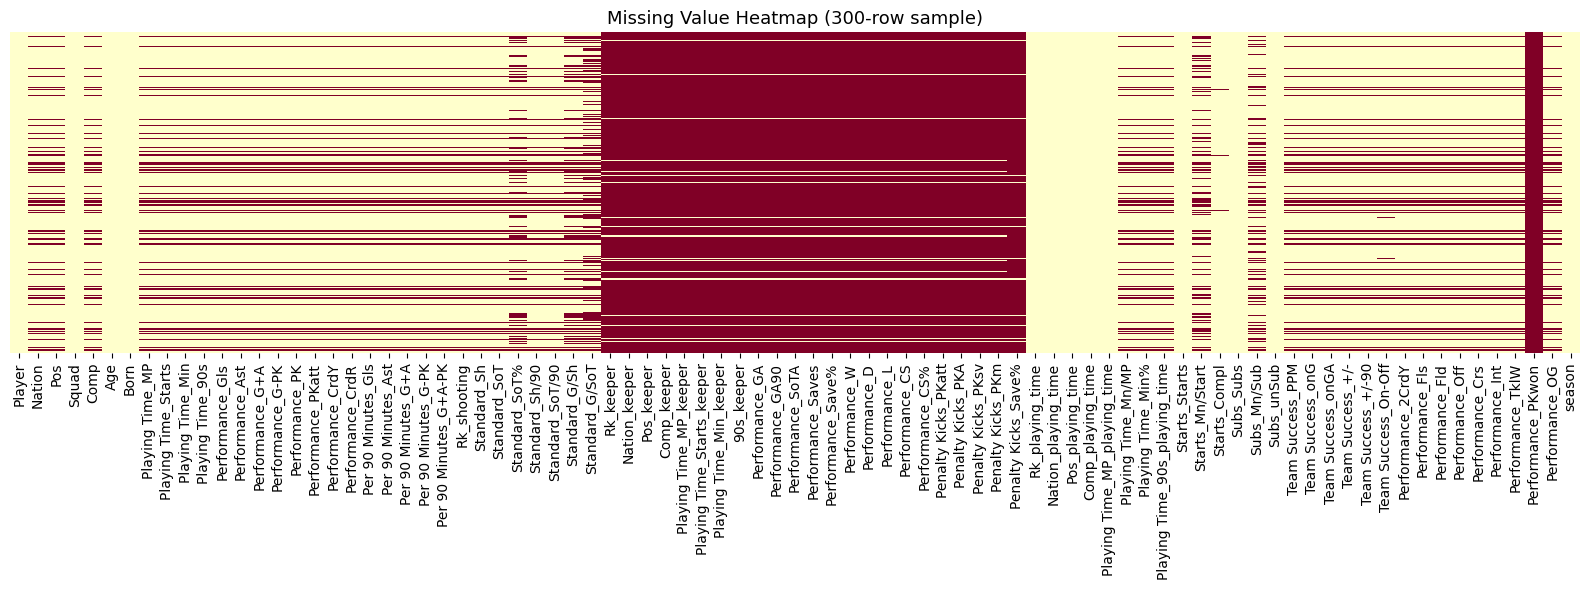

In [52]:
# Visualise missing values (heatmap)
fig, ax = plt.subplots(figsize=(16, 6))
sample_idx = np.random.choice(df.index, 300, replace=False)
sns.heatmap(df.loc[sample_idx].isnull(), cbar=False, yticklabels=False,
            cmap="YlOrRd", ax=ax)
ax.set_title("Missing Value Heatmap (300-row sample)", fontsize=13)
plt.tight_layout()

From the heatmap and it is evident that keeper related columns are occuring the massive pile of missing values.


In [53]:
cols_to_drop_rk = [col for col in df.columns if col.startswith('Rk_')]
if cols_to_drop_rk:
    df = df.drop(columns=cols_to_drop_rk)
    print(f"Dropped columns starting with 'Rk_': {cols_to_drop_rk}")
else:
    print("No columns starting with 'Rk_' found to drop.")

Dropped columns starting with 'Rk_': ['Rk_shooting', 'Rk_keeper', 'Rk_playing_time']


In [54]:
#Duplicate rows er kheta puri

dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {dupes}")

# Player-season-squad duplicates
pid_cols = ["Player", "Squad", "season"]
partial_dupes = df.duplicated(subset=pid_cols).sum()
print(f"Player–Squad–Season duplicates: {partial_dupes}")

Exact duplicate rows: 0
Player–Squad–Season duplicates: 1


In [55]:
df[df.duplicated(subset=pid_cols, keep=False)]

,Player,Nation,Pos,Squad,Comp,Age,Born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,...,Performance_2CrdY,Performance_Fls,Performance_Fld,Performance_Off,Performance_Crs,Performance_Int,Performance_TklW,Performance_PKwon,Performance_OG,season
585,Alberto López,NaN,NaN,Sevilla,NaN,20.0,2003.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-2025
588,Alberto López,NaN,NaN,Sevilla,NaN,19.0,2005.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-2025


In [56]:
df.drop_duplicates(subset=pid_cols, keep='first', inplace=True)

In [57]:
# Calculate the percentage of missing values for each row
missing_pct_per_row = (df.isnull().sum(axis=1) / len(df.columns)) * 100

# Filter rows where the missing percentage is greater than 75%
high_missing_rows = df[missing_pct_per_row > 75]

print(f"Number of rows with more than 75% missing values: {len(high_missing_rows)}")
display(high_missing_rows)

Number of rows with more than 75% missing values: 3937


,Player,Nation,Pos,Squad,Comp,Age,Born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,...,Performance_2CrdY,Performance_Fls,Performance_Fld,Performance_Off,Performance_Crs,Performance_Int,Performance_TklW,Performance_PKwon,Performance_OG,season
2,Aaron Anselmino,NaN,NaN,Chelsea,NaN,19.0,2005.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-2025
4,Aaron Ciammaglichella,NaN,NaN,Torino,NaN,17.0,2005.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-2023
5,Aaron Ciammaglichella,NaN,NaN,Torino,NaN,18.0,2005.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-2024
17,Aaron Hickey,NaN,NaN,Brentford,NaN,22.0,2002.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-2025
19,Aaron Kamardin,NaN,NaN,Marseille,NaN,18.0,2002.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21057,Óttar Magnús Karlsson,NaN,NaN,Venezia,NaN,24.0,1997.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-2022
21066,Þórir Jóhann Helgason,NaN,NaN,Lecce,NaN,22.0,2000.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-2024
21075,İlkay Gündoğan,NaN,NaN,Manchester City,NaN,35.0,1990.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-2026
21078,İsak Vural,NaN,NaN,Frosinone,NaN,17.0,2006.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-2024


In [58]:
df.drop(high_missing_rows.index, inplace=True)

In [59]:
df.shape

(17149, 82)

In [60]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 17149 entries, 0 to 21099
Data columns (total 82 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Player                         17149 non-null  object 
 1   Nation                         17141 non-null  object 
 2   Pos                            17149 non-null  object 
 3   Squad                          17149 non-null  object 
 4   Comp                           17149 non-null  object 
 5   Age                            17146 non-null  float64
 6   Born                           17149 non-null  float64
 7   Playing Time_MP                17149 non-null  float64
 8   Playing Time_Starts            17149 non-null  float64
 9   Playing Time_Min               17149 non-null  float64
 10  Playing Time_90s               17149 non-null  float64
 11  Performance_Gls                17149 non-null  float64
 12  Performance_Ast                17149 non-null  floa

In [61]:
goals_assists_cols = [
    'Performance_G+A', 'Performance_Gls', 'Performance_Ast',
    'Per 90 Minutes_Gls', 'Per 90 Minutes_Ast', 'Per 90 Minutes_G+A'
]

# Ensure only existing columns are selected
goals_assists_cols = [col for col in goals_assists_cols if col in df.columns]

# Calculate the correlation matrix for these specific columns
correlation_subset = df[goals_assists_cols].corr()

print("Intercorrelation between Performance_G+A and other goal/assist columns:")
display(correlation_subset)

Intercorrelation between Performance_G+A and other goal/assist columns:


,Performance_G+A,Performance_Gls,Performance_Ast,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A
Performance_G+A,1.000000,0.933383,0.811513,0.451966,0.167032,0.393697
Performance_Gls,0.933383,1.000000,0.547746,0.516936,0.088314,0.370218
Performance_Ast,0.811513,0.547746,1.000000,0.211969,0.245601,0.315016
Per 90 Minutes_Gls,0.451966,0.516936,0.211969,1.000000,0.058321,0.628277
Per 90 Minutes_Ast,0.167032,0.088314,0.245601,0.058321,1.000000,0.813274
Per 90 Minutes_G+A,0.393697,0.370218,0.315016,0.628277,0.813274,1.000000


In [62]:
columns_to_drop = ['Performance_Gls', 'Performance_Ast']
df.drop(columns=columns_to_drop, inplace=True)
print(f"Dropped columns: {columns_to_drop}")
print(f"DataFrame shape after dropping columns: {df.shape}")

Dropped columns: ['Performance_Gls', 'Performance_Ast']
DataFrame shape after dropping columns: (17149, 80)


In [63]:
# Filter rows where 'Nation' is missing
nation_missing_rows = df[df['Nation'].isna()].copy()

# Calculate the percentage of missing values for each of these rows
nation_missing_rows['Missing_Percentage'] = (nation_missing_rows.isnull().sum(axis=1) / len(nation_missing_rows.columns)) * 100

print(f"Number of rows with missing 'Nation' before imputation: {len(nation_missing_rows)}")
display(nation_missing_rows[['Player', 'Nation', 'Missing_Percentage']])

# Impute the missing 'Nation' values based on internet search
df.loc[df['Player'] == 'Jeremy Ngakia', 'Nation'] = 'eng ENG'
df.loc[df['Player'] == 'Luis Orejuela', 'Nation'] = 'co COL'
df.loc[df['Player'] == 'Mahmut Kücüksahin', 'Nation'] = 'tr TUR'
df.loc[df['Player'] == 'Nathan Mbala', 'Nation'] = 'fr FRA'
df.loc[df['Player'] == 'Olabade Aluko', 'Nation'] = 'eng ENG'
df.loc[df['Player'] == 'Plamedi Nsingi', 'Nation'] = 'cd COD'
df.loc[df['Player'] == 'Sidnei Tavares', 'Nation'] = 'pt POR'
df.loc[df['Player'] == 'Yael Trepy', 'Nation'] = 'fr FRA'


# Display the players whose nation was just imputed for verification
imputed_players = [
    'Jeremy Ngakia', 'Luis Orejuela', 'Mahmut Kücüksahin', 'Nathan Mbala',
    'Olabade Aluko', 'Yael Trepy', 'Plamedi Nsingi', 'Sidnei Tavares'
]
display(df[df['Player'].isin(imputed_players)][['Player', 'Nation']])

Number of rows with missing 'Nation' before imputation: 8


,Player,Nation,Missing_Percentage
9105,Jeremy Ngakia,NaN,32.50
12137,Luis Orejuela,NaN,35.00
12401,Mahmut Kücüksahin,NaN,36.25
14787,Nathan Mbala,NaN,31.25
15507,Olabade Aluko,NaN,37.50
16441,Plamedi Nsingi,NaN,32.50
18346,Sidnei Tavares,NaN,31.25
20391,Yael Trepy,NaN,33.75


,Player,Nation
9105,Jeremy Ngakia,eng ENG
12137,Luis Orejuela,co COL
12401,Mahmut Kücüksahin,tr TUR
14787,Nathan Mbala,fr FRA
15507,Olabade Aluko,eng ENG
16441,Plamedi Nsingi,cd COD
18346,Sidnei Tavares,pt POR
20391,Yael Trepy,fr FRA


- As I can see, these rows contain nearly 70% of the data. Since only the Nation column has missing values, I don't think it's a good idea to drop the entire row. Instead, we should manually collect the missing data from Google and impute those values

In [64]:
df.drop(columns=['Performance_PKwon'], inplace=True)

- Dropped as all the values in this column are null

In [65]:
columns_to_drop_keeper = [col for col in df.columns if col.endswith('_keeper')]

if columns_to_drop_keeper:
    df.drop(columns=columns_to_drop_keeper, inplace=True)
    print(f"Dropped columns ending with '_keeper': {columns_to_drop_keeper}")
    print(f"New DataFrame shape: {df.shape}")
else:
    print("No columns ending with '_keeper' found.")

Dropped columns ending with '_keeper': ['Nation_keeper', 'Pos_keeper', 'Comp_keeper', 'Playing Time_MP_keeper', 'Playing Time_Starts_keeper', 'Playing Time_Min_keeper', '90s_keeper']
New DataFrame shape: (17149, 72)


- Columns that end with ***_keeper*** are duplicated versions of the outfield player columns. I also verified that the corresponding outfield player columns contain the same data as the _keeper columns. After confirming this, I decided to drop all columns ending with _keeper.

In [66]:
columns_to_drop_playing_time = [col for col in df.columns if 'playing_time' in col.lower()]

if columns_to_drop_playing_time:
    df.drop(columns=columns_to_drop_playing_time, inplace=True)
    print(f"Dropped columns containing 'playing_time': {columns_to_drop_playing_time}")
    print(f"New DataFrame shape: {df.shape}")
else:
    print("No columns containing 'playing_time' found.")

Dropped columns containing 'playing_time': ['Nation_playing_time', 'Pos_playing_time', 'Comp_playing_time', 'Playing Time_MP_playing_time', 'Playing Time_90s_playing_time']
New DataFrame shape: (17149, 67)


- Columns that have  ***playing_time*** are duplicated columns. I have checked and decided to drop all columns that have playing_time.

In [67]:
if 'Starts_Starts' in df.columns:
    df.drop(columns=['Starts_Starts'], inplace=True)
    print("Column 'Starts_Starts' dropped successfully.")
    print(f"New DataFrame shape: {df.shape}")
else:
    print("Column 'Starts_Starts' not found in the DataFrame.")

Column 'Starts_Starts' dropped successfully.
New DataFrame shape: (17149, 66)


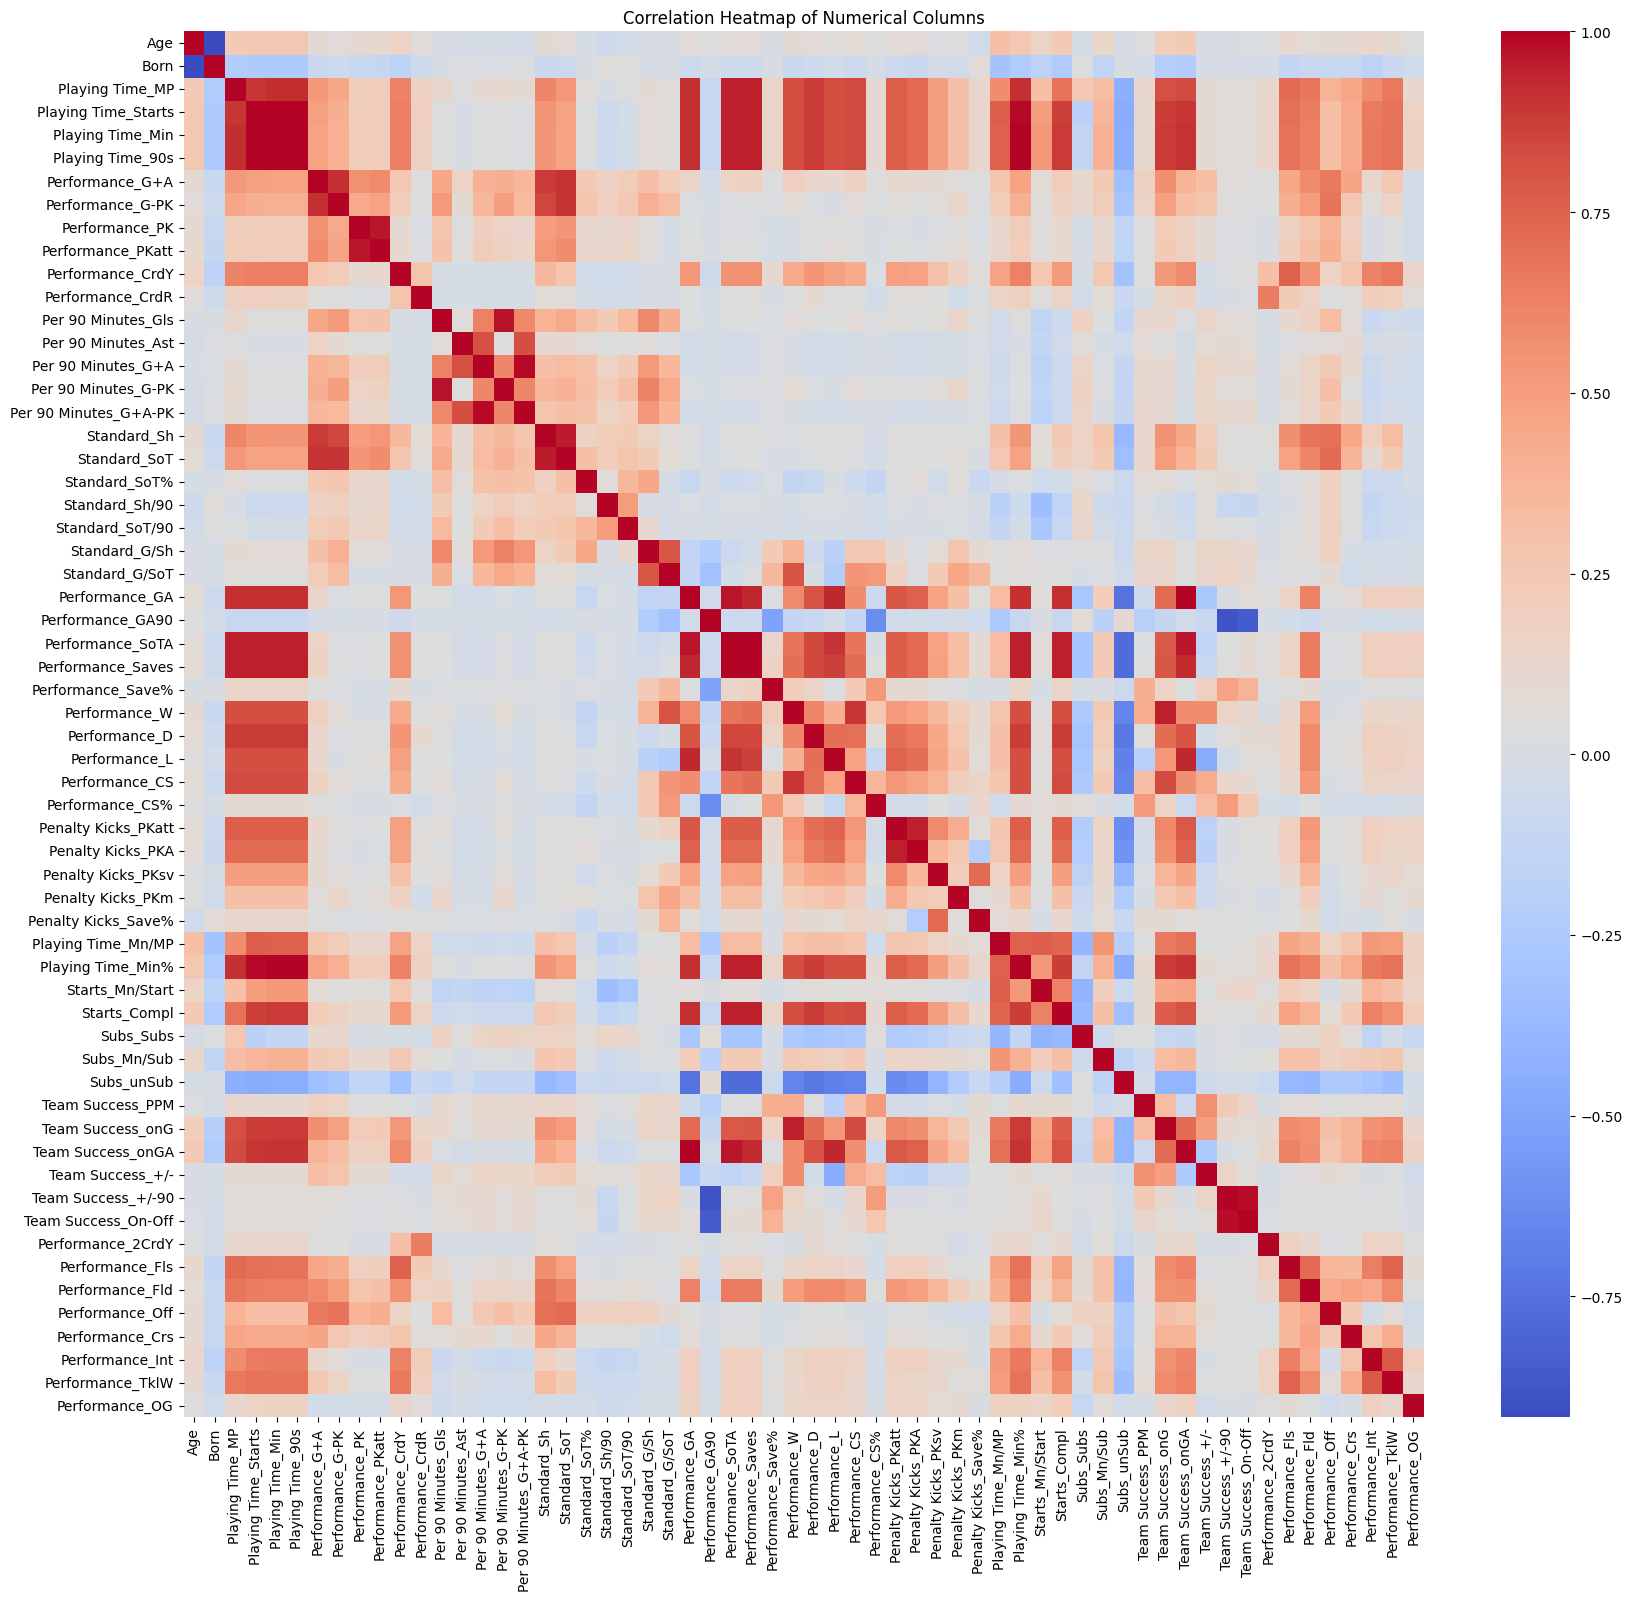

In [68]:
numerical_df = df.select_dtypes(include=[np.number])

correlation_matrix = numerical_df.corr()

plt.figure(figsize=(20, 18)) # Adjust figure size for better readability
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

In [69]:
highly_correlated_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.95:
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]
            correlation_value = correlation_matrix.iloc[i, j]
            highly_correlated_pairs.append((col1, col2, correlation_value))

print("Highly correlated pairs (absolute correlation > 0.95):")
if highly_correlated_pairs:
    all_correlated_columns = set()
    for col1, col2, correlation_value in highly_correlated_pairs:
        print(f"- {col1} and {col2}: {correlation_value:.2f}")
        all_correlated_columns.add(col1)
        all_correlated_columns.add(col2)

    print(f"\nUnique columns involved in highly correlated pairs: {sorted(list(all_correlated_columns))}")
else:
    print("No highly correlated pairs found (absolute correlation > 0.95).")

Highly correlated pairs (absolute correlation > 0.95):
- Playing Time_MP and Performance_SoTA: 0.95
- Playing Time_Starts and Playing Time_Min: 0.99
- Playing Time_Starts and Playing Time_90s: 0.99
- Playing Time_Starts and Performance_SoTA: 0.95
- Playing Time_Starts and Performance_Saves: 0.95
- Playing Time_Starts and Playing Time_Min%: 0.99
- Playing Time_Min and Playing Time_90s: 1.00
- Playing Time_Min and Performance_SoTA: 0.95
- Playing Time_Min and Performance_Saves: 0.95
- Playing Time_Min and Playing Time_Min%: 1.00
- Playing Time_90s and Performance_SoTA: 0.95
- Playing Time_90s and Performance_Saves: 0.95
- Playing Time_90s and Playing Time_Min%: 1.00
- Performance_PK and Performance_PKatt: 0.97
- Per 90 Minutes_Gls and Per 90 Minutes_G-PK: 0.97
- Per 90 Minutes_G+A and Per 90 Minutes_G+A-PK: 0.99
- Standard_Sh and Standard_SoT: 0.96
- Performance_GA and Performance_SoTA: 0.97
- Performance_GA and Team Success_onGA: 1.00
- Performance_SoTA and Performance_Saves: 0.99
- Per

- Performance_PK and Performance_PKatt: 0.97
Not gonna drop it as pkatt means penalty kick attempted. This will help us to predict penalty shootout related stuffs. Also it gives a good insight about penalty kick conversion.


In [70]:
import pandas as pd
import numpy as np

def resolve_high_correlations(df: pd.DataFrame, threshold: float = 0.90) -> pd.DataFrame:
    df = df.copy()
    dropped_log = []
    excluded_pairs = set()  # pairs the user chose to keep as-is

    while True:
        numeric_df = df.select_dtypes(include="number")
        corr_matrix = numeric_df.corr()

        # Find the single highest-correlation pair remaining above threshold,
        # skipping any pair the user already chose to keep.
        best_pair = None
        best_val = threshold
        cols = corr_matrix.columns
        for i in range(len(cols)):
            for j in range(i + 1, len(cols)):
                if frozenset((cols[i], cols[j])) in excluded_pairs:
                    continue
                val = corr_matrix.iloc[i, j]
                if abs(val) > best_val:
                    best_val = abs(val)
                    best_pair = (cols[i], cols[j], val)

        if best_pair is None:
            print("\nNo more column pairs above the threshold. Done.")
            break

        col1, col2, corr_value = best_pair

        print(f"\n'{col1}' and '{col2}' have a correlation of {corr_value:.2f}.")
        print(f"  1) Keep '{col1}' (drop '{col2}')")
        print(f"  2) Keep '{col2}' (drop '{col1}')")
        print(f"  3) Keep both (skip this pair)")

        choice = input("Which do you want? [1/2/3]: ").strip()

        if choice == "1":
            df.drop(columns=[col2], inplace=True)
            dropped_log.append((col2, f"correlated with kept column '{col1}' ({corr_value:.2f})"))
            print(f"Dropped '{col2}'.")
        elif choice == "2":
            df.drop(columns=[col1], inplace=True)
            dropped_log.append((col1, f"correlated with kept column '{col2}' ({corr_value:.2f})"))
            print(f"Dropped '{col1}'.")
        elif choice == "3":
            print(f"Keeping both '{col1}' and '{col2}'. Won't ask about this exact pair again.")
            excluded_pairs.add(frozenset((col1, col2)))
        else:
            print("Please enter 1, 2, or 3.")
            continue

    print(f"\nTotal columns dropped: {len(dropped_log)}")
    for col, reason in dropped_log:
        print(f"  - {col}: {reason}")
    print(f"Final DataFrame shape: {df.shape}")

    return df


# Use the existing 'df' DataFrame and update it with the cleaned version
df = resolve_high_correlations(df, threshold=0.90)


'Playing Time_Min' and 'Playing Time_90s' have a correlation of 1.00.
  1) Keep 'Playing Time_Min' (drop 'Playing Time_90s')
  2) Keep 'Playing Time_90s' (drop 'Playing Time_Min')
  3) Keep both (skip this pair)
Which do you want? [1/2/3]: 1
Dropped 'Playing Time_90s'.

'Playing Time_Min' and 'Playing Time_Min%' have a correlation of 1.00.
  1) Keep 'Playing Time_Min' (drop 'Playing Time_Min%')
  2) Keep 'Playing Time_Min%' (drop 'Playing Time_Min')
  3) Keep both (skip this pair)
Which do you want? [1/2/3]: 1
Dropped 'Playing Time_Min%'.

'Performance_GA' and 'Team Success_onGA' have a correlation of 1.00.
  1) Keep 'Performance_GA' (drop 'Team Success_onGA')
  2) Keep 'Team Success_onGA' (drop 'Performance_GA')
  3) Keep both (skip this pair)
Which do you want? [1/2/3]: 1
Dropped 'Team Success_onGA'.

'Playing Time_Starts' and 'Playing Time_Min' have a correlation of 0.99.
  1) Keep 'Playing Time_Starts' (drop 'Playing Time_Min')
  2) Keep 'Playing Time_Min' (drop 'Playing Time_Star

In [71]:
df.dropna(subset=['Team Success_PPM'], inplace=True)
print(f"DataFrame shape after dropping rows with missing Team Success_PPM: {df.shape}")

DataFrame shape after dropping rows with missing Team Success_PPM: (17140, 58)


In [72]:
player_names = ['Frank Feller', 'Pietro Terracciano']

# Identify rows where Performance_CS% is > 100 for the specified players
mask_inconsistency = (df['Player'].isin(player_names)) & (df['Performance_CS%'] > 100)

# Display the inconsistent rows before correction
print("Rows with inconsistent 'Performance_CS%' before correction:")
display(df[mask_inconsistency][['Player', 'Performance_CS%']])

# Correct the inconsistent values by capping at 100%
df.loc[mask_inconsistency, 'Performance_CS%'] = 100.0

# Display the corrected rows for verification
print("\nRows with 'Performance_CS%' after correction:")
display(df[df['Player'].isin(player_names)][['Player', 'Performance_CS%']])

Rows with inconsistent 'Performance_CS%' before correction:


,Player,Performance_CS%
6561,Frank Feller,200.0
16426,Pietro Terracciano,200.0



Rows with 'Performance_CS%' after correction:


,Player,Performance_CS%
6561,Frank Feller,100.0
6563,Frank Feller,0.0
16426,Pietro Terracciano,100.0
16427,Pietro Terracciano,24.2
16428,Pietro Terracciano,17.2
16429,Pietro Terracciano,33.3
16430,Pietro Terracciano,100.0
16431,Pietro Terracciano,29.0


In [73]:
output_path = '/content/drive/MyDrive/cleaned.v2_tree.csv'
df.to_csv(output_path, index=False)
print(f"Cleaned DataFrame saved to {output_path}")

Cleaned DataFrame saved to /content/drive/MyDrive/cleaned.v2_tree.csv
